In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the style for all plots
plt.style.use('seaborn-v0_8')  # Using a valid style name
sns.set_theme(style="whitegrid")  # Setting seaborn theme

In [29]:
# Read and process EV registration data
df_reg = pd.read_csv('ev_registration_counts_by_state.csv', skiprows=1, usecols=[0, 1])
df_reg.columns = ['State', 'Registration Count']
df_reg['Registration Count'] = df_reg['Registration Count'].str.replace(',', '').astype(int)
high_registration_states = df_reg[df_reg['Registration Count'] > 50000]
high_registration_states = high_registration_states.sort_values('Registration Count', ascending=False)
high_registration_states = high_registration_states.dropna()

print("\nHigh registration states data:")
print(high_registration_states)


High registration states data:
             State  Registration Count
51           Total             3555445
4       California             1256646
9          Florida              254878
43           Texas              230125
47      Washington              152101
30      New Jersey              134753
32        New York              131250
13        Illinois               99573
10         Georgia               92368
5         Colorado               90083
2          Arizona               89798
46        Virginia               84936
21   Massachusetts               73768
20        Maryland               72139
33  North Carolina               70164
38    Pennsylvania               70154
37          Oregon               64361
35            Ohio               50393
22        Michigan               50284


In [42]:
print("\nStates with more than 50,000 EV registrations:")
print(high_registration_states)
print("\nTop 10 states by number of charging stations:")
print(station_counts)
print("\nShape of station_counts:", station_counts.shape)
print("\nStation counts data type:", station_counts.dtype)
print("\nStation counts values:", station_counts.values)
print("\nStation counts index:", station_counts.index)


States with more than 50,000 EV registrations:
             State  Registration Count
51           Total             3555445
4       California             1256646
9          Florida              254878
43           Texas              230125
47      Washington              152101
30      New Jersey              134753
32        New York              131250
13        Illinois               99573
10         Georgia               92368
5         Colorado               90083
2          Arizona               89798
46        Virginia               84936
21   Massachusetts               73768
20        Maryland               72139
33  North Carolina               70164
38    Pennsylvania               70154
37          Oregon               64361
35            Ohio               50393
22        Michigan               50284

Top 10 states by number of charging stations:
State
CA    16317
NY     3911
FL     3347
TX     3109
MA     3021
WA     2208
CO     2175
GA     1938
MD     1706
PA     1689

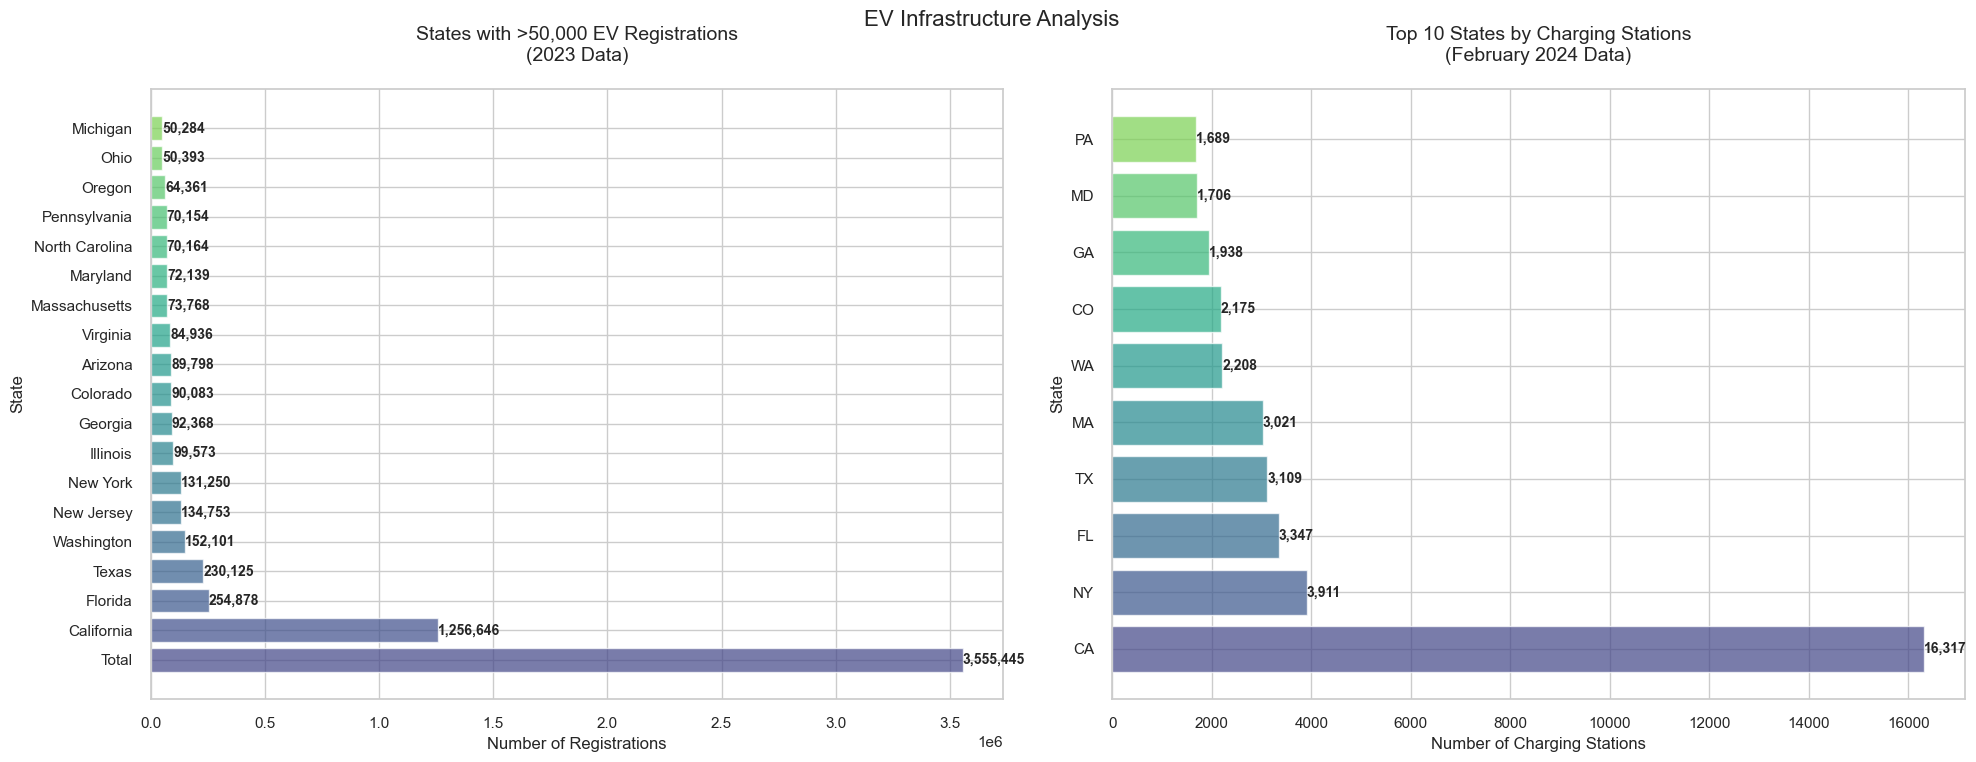

In [33]:
# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('EV Infrastructure Analysis', fontsize=16, y=0.95)

# Plot 1: EV Registrations with gradient colors
if not high_registration_states.empty:
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(high_registration_states)))
    bars1 = ax1.barh(high_registration_states['State'], high_registration_states['Registration Count'], 
                    color=colors, alpha=0.7)
    ax1.set_title('States with >50,000 EV Registrations\n(2023 Data)', fontsize=14, pad=20)
    ax1.set_xlabel('Number of Registrations', fontsize=12)
    ax1.set_ylabel('State', fontsize=12)
    for bar in bars1:
        width = bar.get_width()
        ax1.text(width, bar.get_y() + bar.get_height()/2, f'{int(width):,}', 
                ha='left', va='center', fontsize=10, fontweight='bold')
else:
    ax1.text(0.5, 0.5, 'No states with >50,000 registrations', 
            ha='center', va='center', fontsize=12)
    ax1.set_title('States with >50,000 EV Registrations\n(2023 Data)', fontsize=14, pad=20)

# Plot 2: Charging Stations with gradient colors
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(station_counts)))
bars2 = ax2.barh(station_counts.index, station_counts.values, color=colors, alpha=0.7)
ax2.set_title('Top 10 States by Charging Stations\n(February 2024 Data)', fontsize=14, pad=20)
ax2.set_xlabel('Number of Charging Stations', fontsize=12)
ax2.set_ylabel('State', fontsize=12)
for bar in bars2:
    width = bar.get_width()
    ax2.text(width, bar.get_y() + bar.get_height()/2, f'{int(width):,}', 
            ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

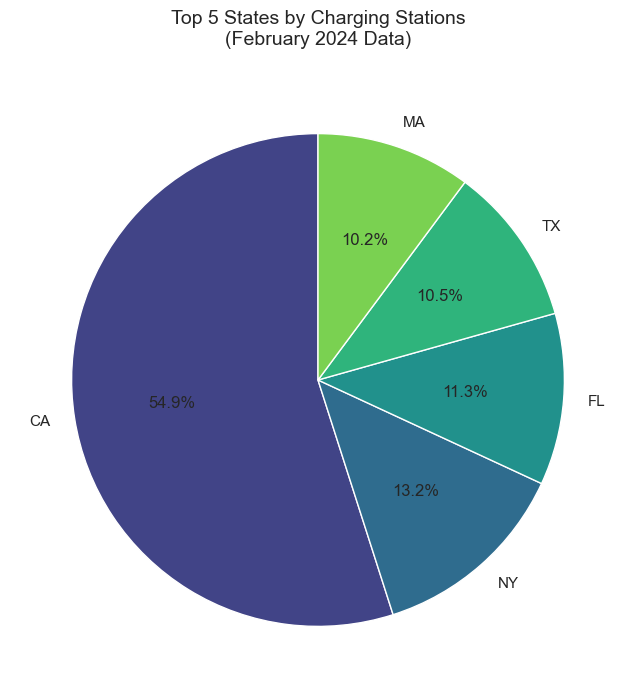

In [32]:
# Create a pie chart for top 5 states by charging stations
plt.figure(figsize=(12, 8))
plt.pie(station_counts.head(5), labels=station_counts.head(5).index, autopct='%1.1f%%',
        colors=plt.cm.viridis(np.linspace(0.2, 0.8, 5)), startangle=90)
plt.title('Top 5 States by Charging Stations\n(February 2024 Data)', fontsize=14, pad=20)
plt.show()

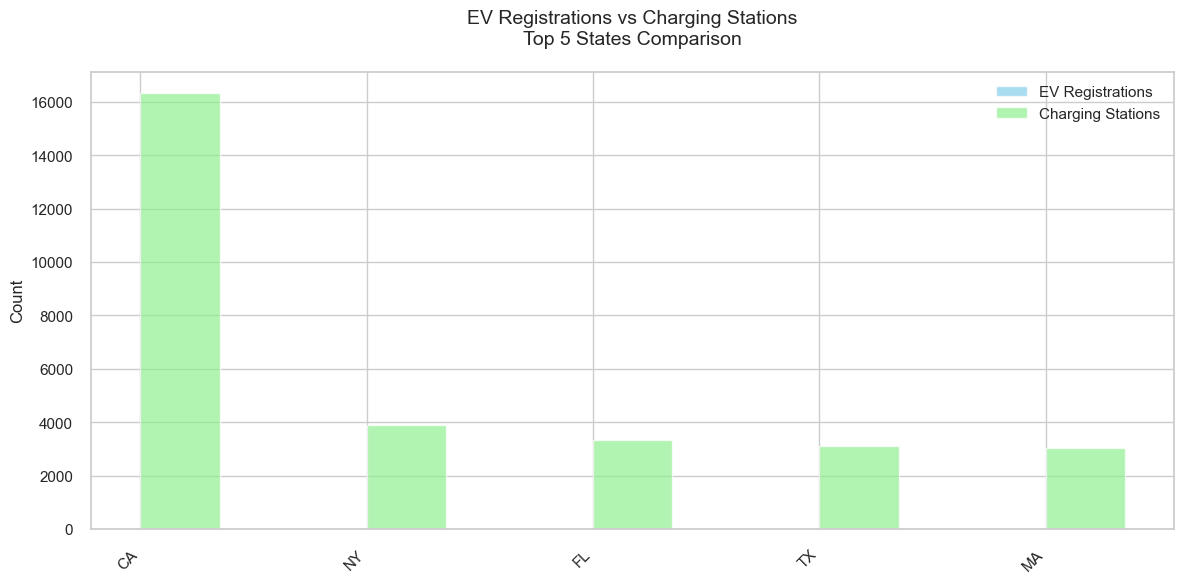

In [38]:
# Create a stacked bar chart comparing top 5 states
top_5_states = station_counts.head(5).index
reg_data = df_reg[df_reg['State'].isin(top_5_states)]
reg_data = reg_data.set_index('State')

# Ensure both series have the same index order
reg_data = reg_data.reindex(top_5_states)
station_counts_top5 = station_counts[top_5_states]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(top_5_states))
width = 0.35

# Plot bars
ax.bar(x - width/2, reg_data['Registration Count'].values, width, 
       label='EV Registrations', color='skyblue', alpha=0.7)
ax.bar(x + width/2, station_counts_top5.values, width, 
       label='Charging Stations', color='lightgreen', alpha=0.7)

ax.set_ylabel('Count', fontsize=12)
ax.set_title('EV Registrations vs Charging Stations\nTop 5 States Comparison', fontsize=14, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(top_5_states, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

In [49]:
import folium
import pandas as pd
import numpy as np

# Create a dictionary of state coordinates (centers of states)
state_coords = {
    'Alabama': [32.7794, -86.8287],
    'Alaska': [64.8568, -147.8028],
    'Arizona': [34.2744, -111.6602],
    'Arkansas': [34.7465, -92.2896],
    'California': [36.7783, -119.4179],
    'Colorado': [39.1136, -105.3589],
    'Connecticut': [41.5978, -72.7554],
    'Delaware': [39.3223, -75.5288],
    'Florida': [27.6648, -81.5158],
    'Georgia': [32.6415, -83.4426],
    'Hawaii': [20.7984, -156.3319],
    'Idaho': [44.2405, -114.4788],
    'Illinois': [40.0417, -88.2732],
    'Indiana': [39.8494, -86.2583],
    'Iowa': [42.0751, -93.4960],
    'Kansas': [38.5266, -96.7265],
    'Kentucky': [37.6681, -84.6701],
    'Louisiana': [31.1695, -91.8678],
    'Maine': [45.2538, -69.4455],
    'Maryland': [39.0458, -76.6413],
    'Massachusetts': [42.2302, -71.5301],
    'Michigan': [44.3148, -85.6024],
    'Minnesota': [46.2807, -94.3053],
    'Mississippi': [32.7364, -89.6678],
    'Missouri': [38.4561, -92.2884],
    'Montana': [46.9219, -110.4544],
    'Nebraska': [41.5378, -99.7951],
    'Nevada': [38.4192, -117.1219],
    'New Hampshire': [43.1939, -71.5724],
    'New Jersey': [40.0583, -74.4057],
    'New Mexico': [34.8405, -106.2485],
    'New York': [42.1657, -74.9481],
    'North Carolina': [35.7806, -80.2910],
    'North Dakota': [47.5289, -100.3020],
    'Ohio': [40.4173, -82.9071],
    'Oklahoma': [35.5653, -96.9289],
    'Oregon': [44.5720, -122.0709],
    'Pennsylvania': [40.5908, -77.2098],
    'Rhode Island': [41.6809, -71.5118],
    'South Carolina': [33.8361, -81.1637],
    'South Dakota': [44.4443, -100.2263],
    'Tennessee': [35.7478, -86.6923],
    'Texas': [31.9686, -99.9018],
    'Utah': [39.3210, -111.0937],
    'Vermont': [44.0459, -72.7107],
    'Virginia': [37.5407, -77.4360],
    'Washington': [47.7511, -120.7401],
    'West Virginia': [38.5976, -80.4549],
    'Wisconsin': [44.2685, -89.6165],
    'Wyoming': [42.7475, -107.2085]
}

# Create a map centered on the US with a different tile layer
m = folium.Map(location=[39.8283, -98.5795], 
               zoom_start=4,
               tiles='cartodbpositron')  # Cleaner, lighter map style

# Add markers for states with EV registrations
for state, count in zip(high_registration_states['State'], high_registration_states['Registration Count']):
    if state in state_coords:
        folium.CircleMarker(
            location=state_coords[state],
            radius=count/5000,  # Smaller radius (adjusted from 1000 to 5000)
            popup=f'<b>{state}</b><br>EV Registrations: {count:,}<br>Year: 2023',
            color='#1f77b4',  # Darker blue
            fill=True,
            fill_color='#1f77b4',
            fill_opacity=0.6,
            weight=1
        ).add_to(m)

# Add markers for states with charging stations
for state, count in station_counts.items():
    if state in state_coords:
        folium.CircleMarker(
            location=state_coords[state],
            radius=count/50,  # Smaller radius (adjusted from 10 to 50)
            popup=f'<b>{state}</b><br>Charging Stations: {count:,}<br>Data: Feb 2024',
            color='#d62728',  # Darker red
            fill=True,
            fill_color='#d62728',
            fill_opacity=0.6,
            weight=1
        ).add_to(m)

# Add a legend
legend_html = '''
<div style="position: fixed; 
            bottom: 50px; left: 50px; width: 150px; height: 90px; 
            border:2px solid grey; z-index:9999; font-size:14px;
            background-color: white;
            padding: 10px;
            border-radius: 5px;
            ">
            <p><i class="fa fa-circle" style="color:#1f77b4"></i> EV Registrations</p>
            <p><i class="fa fa-circle" style="color:#d62728"></i> Charging Stations</p>
            <p><small>Circle size indicates relative count</small></p>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

# Add a title
title_html = '''
<div style="position: fixed; 
            top: 10px; left: 50px; width: 300px; height: 40px; 
            z-index:9999; font-size:16px;
            background-color: white;
            padding: 10px;
            border-radius: 5px;
            border:2px solid grey;
            ">
            <b>US EV Infrastructure Map</b>
</div>
'''
m.get_root().html.add_child(folium.Element(title_html))

# Save the map
m.save('us_ev_map.html')

# Display the map
m

In [44]:
pip install folium



[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: /opt/homebrew/Cellar/jupyterlab/4.3.4_1/libexec/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [47]:
pip install --upgrade pip


  Using cached pip-25.0.1-py3-none-any.whl.metadata (3.7 kB)
Using cached pip-25.0.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 25.0
    Uninstalling pip-25.0:
      Successfully uninstalled pip-25.0
Note: you may need to restart the kernel to use updated packages.
